In [1]:
import pandas as pd
import numpy as np
# this results is from 417 galaxies base samples
sample = pd.read_csv('/data/zsl23/preparation/basemJynan_new.txt', sep="\s+", header = 0)
checksample = pd.read_csv('/data/zsl23/checkbase.txt', sep="\s+", header = 0)
wrongsample = pd.read_csv('/data/zsl23/basemodels/basegalmJynan.txt', sep="\s+", header = 0)

In [2]:
sample.equals(checksample)

True

In [3]:
checksample.equals(wrongsample)

False

In [4]:
list(sample)

['#id',
 'redshift',
 'distance',
 'galex.FUV',
 'galex.FUV_err',
 'galex.NUV',
 'galex.NUV_err',
 'sloan.sdss.u',
 'sloan.sdss.u_err',
 'sloan.sdss.g',
 'sloan.sdss.g_err',
 'sloan.sdss.r',
 'sloan.sdss.r_err',
 'sloan.sdss.i',
 'sloan.sdss.i_err',
 'sloan.sdss.z',
 'sloan.sdss.z_err',
 '2mass.J',
 '2mass.J_err',
 '2mass.H',
 '2mass.H_err',
 '2mass.Ks',
 '2mass.Ks_err',
 'wise.W1',
 'wise.W1_err',
 'wise.W2',
 'wise.W2_err',
 'wise.W3',
 'wise.W3_err',
 'wise.W4',
 'wise.W4_err',
 'spitzer.irac.I1',
 'spitzer.irac.I1_err',
 'spitzer.irac.I2',
 'spitzer.irac.I2_err',
 'spitzer.irac.I3',
 'spitzer.irac.I3_err',
 'spitzer.irac.I4',
 'spitzer.irac.I4_err',
 'spitzer.mips.24mu',
 'spitzer.mips.24mu_err',
 'spitzer.mips.70mu',
 'spitzer.mips.70mu_err',
 'spitzer.mips.160mu',
 'spitzer.mips.160mu_err',
 'herschel.pacs.blue',
 'herschel.pacs.blue_err',
 'herschel.pacs.green',
 'herschel.pacs.green_err',
 'herschel.pacs.red',
 'herschel.pacs.red_err',
 'herschel.spire.PSW',
 'herschel.spire.PS

In [5]:
columns_to_null_1 = [
    'wise.W4', 'wise.W4_err',
    'spitzer.mips.24mu', 'spitzer.mips.24mu_err',
    'spitzer.mips.70mu', 'spitzer.mips.70mu_err',
    'spitzer.mips.160mu', 'spitzer.mips.160mu_err',
    'herschel.pacs.blue', 'herschel.pacs.blue_err',
    'herschel.pacs.green', 'herschel.pacs.green_err',
    'herschel.pacs.red', 'herschel.pacs.red_err',
    'herschel.spire.PSW', 'herschel.spire.PSW_err',
    'herschel.spire.PMW', 'herschel.spire.PMW_err',
    'herschel.spire.PLW', 'herschel.spire.PLW_err'
]
nofirsample = sample.copy()
nofirsample[columns_to_null_1] = np.nan

In [6]:
nofirsample.to_csv('nofir.txt' ,sep=' ', index=False, na_rep='NaN') # to be used in CIGALE

In [7]:
# read in the results
nofirresults = pd.read_csv('/data/zsl23/80milmodels/nofirresults.txt', sep="\s+", header = 0)
baseresults = pd.read_csv('/data/zsl23/80milmodels/baseresults.txt', sep="\s+", header = 0)
opticalonlyresults = pd.read_csv('/data/zsl23/80milmodels/opticalonlyresults.txt', sep="\s+", header = 0)

In [8]:
nofirproperties = nofirresults[['id','bayes.stellar.m_star','bayes.stellar.m_star_err','bayes.sfh.sfr','bayes.sfh.sfr_err',
                      'bayes.dust.mass','bayes.dust.mass_err', 'bayes.dust.luminosity','bayes.dust.luminosity_err', 'bayes.dust.alpha',
                      'bayes.dust.alpha_err','bayes.dust.gamma','bayes.dust.gamma_err','bayes.dust.qhac','bayes.dust.qhac_err',
                      'bayes.dust.umin','bayes.dust.umin_err','bayes.attenuation.generic.bessell.V', 'bayes.attenuation.generic.bessell.V_err',
                      'bayes.stellar.age_m_star','bayes.stellar.age_m_star_err']] 

baseproperties = baseresults[['id','bayes.stellar.m_star','bayes.stellar.m_star_err','bayes.sfh.sfr','bayes.sfh.sfr_err',
                      'bayes.dust.mass','bayes.dust.mass_err', 'bayes.dust.luminosity','bayes.dust.luminosity_err', 'bayes.dust.alpha',
                      'bayes.dust.alpha_err','bayes.dust.gamma','bayes.dust.gamma_err','bayes.dust.qhac','bayes.dust.qhac_err',
                      'bayes.dust.umin','bayes.dust.umin_err','bayes.attenuation.generic.bessell.V', 'bayes.attenuation.generic.bessell.V_err',
                      'bayes.stellar.age_m_star','bayes.stellar.age_m_star_err']] 

opticalonlyproperties = opticalonlyresults[['id','bayes.stellar.m_star','bayes.stellar.m_star_err','bayes.sfh.sfr','bayes.sfh.sfr_err',
                      'bayes.dust.mass','bayes.dust.mass_err', 'bayes.dust.luminosity','bayes.dust.luminosity_err', 'bayes.dust.alpha',
                      'bayes.dust.alpha_err','bayes.dust.gamma','bayes.dust.gamma_err','bayes.dust.qhac','bayes.dust.qhac_err',
                      'bayes.dust.umin','bayes.dust.umin_err','bayes.attenuation.generic.bessell.V', 'bayes.attenuation.generic.bessell.V_err',
                      'bayes.stellar.age_m_star','bayes.stellar.age_m_star_err']] 

In [9]:
rename_map = {
    "bayes.stellar.m_star": "Galaxy Mass (solMass)", "bayes.stellar.m_star_err": "Galaxy Mass Error (solMass)",
    "bayes.sfh.sfr": "Star Formation Rate (solMass yr-1)", "bayes.sfh.sfr_err": "Star Formation Rate Error (solMass yr-1)",
    "bayes.dust.mass": "Total Dust Mass (solMass)", "bayes.dust.mass_err": "Total Dust Mass Error (solMass)",
    "bayes.dust.luminosity":"Dust Luminosity (W)", "bayes.dust.luminosity_err":"Dust Luminosity Error (W)",
    "bayes.attenuation.generic.bessell.V": "Av (mag)", "bayes.attenuation.generic.bessell.V_err": "Av Error (mag)",
    "bayes.stellar.age_m_star": "Average Galaxy Age (Myr)", "bayes.stellar.age_m_star_err": "Average Galaxy Age Error (Myr)",
}

nofirproperties = nofirproperties.rename(columns=rename_map)
baseproperties = baseproperties.rename(columns=rename_map)
opticalonlyproperties = opticalonlyproperties.rename(columns=rename_map)

In [10]:
# include hubble type too
distance = pd.read_csv('/data/zsl23/DustPedia_HyperLEDA_Herschel.csv')
hubbletype = distance[['objname','t', 'dist_best']]
baseproperties = pd.merge(baseproperties, hubbletype, left_on='id', right_on='objname').drop(columns='objname')
nofirproperties = pd.merge(nofirproperties, hubbletype, left_on='id', right_on='objname').drop(columns='objname')

In [26]:
filtersetlist = {
    'base': baseproperties,
    'optical': opticalonlyproperties,
    #'uvoptical': uvopticalproperties,
    #'opticalnir': opticalnirproperties,
    #'opticalmir': opticalmirproperties,
    #'opticalfir': opticalfirproperties,
    'nofir': nofirproperties
}
galaxyproplist = {
    'galaxymass' : 'Galaxy Mass (solMass)',
    'sfr' : 'Star Formation Rate (solMass yr-1)',
    'dustmass' : 'Total Dust Mass (solMass)',
    'av' : 'Av (mag)',
    'galaxyage' : 'Average Galaxy Age (Myr)',
    'ssfr':'Specific SFR (yr-1)',
    'dustmass': 'Total Dust Mass (solMass)', 
    'dustlum':'Dust Luminosity (W)'}

galaxyproperrlist = {
    'galaxymasserr' : 'Galaxy Mass Error (solMass)',
    'sfrerr' : 'Star Formation Rate Error (solMass yr-1)',
    'dustmasserr' : 'Total Dust Mass Error (solMass)',
    'averr' : 'Av Error (mag)',
    'galaxyageerr' : 'Average Galaxy Age Error (Myr)',
    'ssfrerr': 'Specific SFR Error (yr-1)',
    'dustlumerr':'Dust Luminosity Error (W)',
    'dustmasserr': 'Total Dust Mass Error (solMass)'}

In [12]:
# now, for specific SFR
for name, df in filtersetlist.items():
    sfr = df['Star Formation Rate (solMass yr-1)']
    sfr_err = df['Star Formation Rate Error (solMass yr-1)']
    mass = df['Galaxy Mass (solMass)']
    mass_err = df['Galaxy Mass Error (solMass)']
    
    ssfr = sfr / mass
    ssfr_err = ssfr * np.sqrt((sfr_err / sfr)**2 + (mass_err / mass)**2) #error propagation
    
    df['Specific SFR (yr-1)'] = ssfr
    df['Specific SFR Error (yr-1)'] = ssfr_err

In [56]:
nofirproperties.to_csv('nofirproperties.csv',index=False)
baseproperties.to_csv('baseproperties.csv',index=False)
baseproperties.head()

,id,Galaxy Mass (solMass),Galaxy Mass Error (solMass),Star Formation Rate (solMass yr-1),Star Formation Rate Error (solMass yr-1),Total Dust Mass (solMass),Total Dust Mass Error (solMass),Dust Luminosity (W),Dust Luminosity Error (W),bayes.dust.alpha,...,Av (mag),Av Error (mag),Average Galaxy Age (Myr),Average Galaxy Age Error (Myr),t,dist_best,Specific SFR (yr-1),Specific SFR Error (yr-1),bayes.colour_u_r,bayes.colour_u_r_err
0,NGC0584,9.583306e+10,1.171397e+10,0.023790,0.016410,1.291993e+36,6.943807e+35,5.583578e+35,1.190926e+35,2.0,...,0.072390,0.015579,6067.896647,1180.023151,-4.7,19.952632,2.482391e-13,1.739015e-13,2.456346,0.071614
1,NGC0586,9.048471e+09,1.570934e+09,0.040284,0.028256,4.915868e+36,1.371132e+36,3.793401e+35,4.784639e+34,2.0,...,0.274057,0.040251,4587.989486,1183.891925,0.7,24.931731,4.452065e-12,3.217012e-12,2.217274,0.083165
2,NGC0678,6.444807e+10,9.223424e+09,0.083906,0.061263,1.975071e+37,4.184584e+36,9.134661e+35,7.989181e+34,2.0,...,0.199237,0.025748,7963.503268,1494.293432,3.0,27.870000,1.301923e-12,9.686748e-13,2.578605,0.111781
3,NGC0855,8.975936e+08,1.960007e+08,0.027076,0.014076,4.024397e+35,1.136447e+35,1.241069e+35,1.443387e+34,2.0,...,0.230131,0.048937,1409.949168,704.396042,-4.8,9.638295,3.016561e-11,1.700944e-11,1.693638,0.086690
4,PGC008962,5.217925e+08,2.155807e+08,0.089609,0.009031,5.346987e+35,9.939652e+35,1.814277e+34,1.067646e+34,2.0,...,0.016576,0.011280,1842.355339,1230.184817,6.9,30.502458,1.717324e-10,7.303229e-11,1.201658,0.106341


In [67]:
baseproperties[baseproperties['Av (mag)']<0.01]

,id,Galaxy Mass (solMass),Galaxy Mass Error (solMass),Star Formation Rate (solMass yr-1),Star Formation Rate Error (solMass yr-1),Total Dust Mass (solMass),Total Dust Mass Error (solMass),Dust Luminosity (W),Dust Luminosity Error (W),bayes.dust.alpha,...,Av (mag),Av Error (mag),Average Galaxy Age (Myr),Average Galaxy Age Error (Myr),t,dist_best,Specific SFR (yr-1),Specific SFR Error (yr-1),bayes.colour_u_r,bayes.colour_u_r_err
15,UGC05340,1.337121e+08,4.853619e+07,0.076438,0.005396,2.486562e+34,9.335411e+34,2.366805e+33,4.403365e+33,2.0,...,0.003089,0.006088,1846.777473,1381.881119,9.7,12.764387,5.716574e-10,2.113932e-10,0.768333,0.068130
42,UGC06016,5.053718e+08,1.864657e+08,0.157385,0.011762,2.993613e+35,7.993815e+35,6.303166e+33,9.249353e+33,2.0,...,0.003839,0.006075,2581.827548,1428.324611,9.9,26.570180,3.114244e-10,1.172390e-10,0.928939,0.079598
47,NGC3458,2.914079e+10,1.994622e+09,0.002207,0.001735,7.435347e+34,2.558920e+35,8.465203e+33,8.903201e+33,2.0,...,0.003570,0.003764,5839.766124,673.699816,-2.0,29.500000,7.573590e-14,5.975557e-14,2.402914,0.045978
102,IC3019,2.076902e+09,3.730391e+08,0.002680,0.001752,4.363984e+34,1.249573e+35,2.613793e+33,2.916604e+33,2.0,...,0.006823,0.007701,3614.847693,1077.616501,-5.0,16.904397,1.290376e-12,8.750103e-13,2.000050,0.060394
120,NGC4200,9.555696e+09,7.536169e+08,0.018105,0.003391,6.612983e+34,2.332188e+35,3.871291e+33,5.681868e+33,2.0,...,0.003521,0.005335,5411.809475,540.987593,-2.0,24.210281,1.894681e-12,3.850696e-13,2.298771,0.056934
130,NGC4215,2.574221e+10,1.970202e+09,0.017810,0.003897,1.251639e+35,3.474901e+35,1.616966e+34,1.602094e+34,2.0,...,0.007441,0.007473,6642.895632,985.041473,-0.9,22.698646,6.918733e-13,1.603643e-13,2.412182,0.073686
140,NGC4239,5.271642e+09,6.395924e+08,0.009437,0.003032,1.783283e+35,3.694698e+35,4.328110e+33,4.912754e+33,2.0,...,0.006807,0.007835,5325.188135,974.090809,-4.5,17.400000,1.790167e-12,6.148262e-13,2.250011,0.073727
149,NGC4255,2.943400e+10,1.471700e+09,0.027960,0.003570,2.293288e+35,5.697229e+35,1.763464e+34,1.673578e+34,2.0,...,0.007929,0.007716,8167.704368,661.384432,-2.0,28.707818,9.499150e-13,1.302667e-13,2.494274,0.048724
153,NGC4270,3.050061e+10,3.247156e+09,0.004513,0.004865,3.988726e+35,9.439741e+35,2.171565e+34,1.977236e+34,2.0,...,0.008833,0.008055,6048.177306,1028.820987,-2.0,24.930000,1.479497e-13,1.602751e-13,2.416300,0.067067
172,PGC040045,3.812185e+07,7.835567e+06,0.000636,0.000315,6.933033e+33,2.017202e+34,2.932086e+32,3.516351e+32,2.0,...,0.009290,0.011237,957.063554,393.707487,9.4,9.289662,1.668003e-11,8.936199e-12,1.481344,0.077329


In [14]:
# now to classify hubble type
colors = {
    'Early type': 'red',
    'Late type': 'mediumblue',
}
alpha = {
    'Early type': 0.8,
    'Late type': 0.5,
}

masks = {
    'Early type': baseproperties['t'] <= 0,
    'Late type': baseproperties['t'] > 0,
}

In [31]:
#a function to plot differences and colour code the morphologies
def plot_differences(baseline, comparison, galaxyprop, galaxyproperr, xlabel, ylabel, location, indication):
    prop = galaxyproplist[galaxyprop]
    properr = galaxyproperrlist[galaxyproperr]
    
    diff = baseline[prop] - comparison[prop]
    diff_err = np.sqrt(baseline[properr]**2 + comparison[properr]**2)
    
    plt.figure(figsize=(8, 6))
    
    if indication == 'Hubble type':
        for hubble_type, rows in masks.items():
            x_values = baseline.loc[rows, prop]
            x_err = baseline.loc[rows, properr]
            x_plot = x_values if galaxyprop in ('av', 'galaxyage', 'ssfr', 'dustlum') else np.log10(x_values)
            x_plot_err = x_err if galaxyprop in ('av', 'galaxyage', 'ssfr', 'dustlum') else np.log10(x_err)
            plt.errorbar(
                x_plot, diff[rows], xerr = x_plot_err, yerr=diff_err[rows], ecolor = 'gray',
                fmt='.', color=colors[hubble_type], alpha=alpha[hubble_type], label=hubble_type)
        plt.legend(title='Hubble Type', loc=location)
    
    if indication == 'U-R colour':
        x_values = baseline[prop]
        x_err = baseline[properr]
        x_plot = x_values if galaxyprop in ('av', 'galaxyage', 'ssfr', 'dustlum') else np.log10(x_values)
        x_plot_err = x_err if galaxyprop in ('av', 'galaxyage', 'ssfr', 'dustlum') else np.log10(x_err)
        plt.errorbar(x_plot, diff, xerr = x_plot_err,yerr=diff_err, fmt='.', ecolor='gray', alpha=0.4, zorder=0)
        sc = plt.scatter(x_plot, diff, c=baseline['bayes.colour_u_r'], cmap='inferno', s=20, zorder=1)
        cbar = plt.colorbar(sc)
        cbar.set_label('Host Galaxy Colour ($u-r$)')

    if indication == 'Distance':
        x_values = baseline[prop]
        x_err = baseline[properr]
        x_plot = x_values if galaxyprop in ('av', 'galaxyage', 'ssfr', 'dustlum') else np.log10(x_values)
        x_plot_err = x_err if galaxyprop in ('av', 'galaxyage', 'ssfr', 'dustlum') else np.log10(x_err)
        plt.errorbar(x_plot, diff, xerr = x_plot_err,yerr=diff_err, fmt='.', ecolor='gray', alpha=0.4, zorder=0)
        sc = plt.scatter(x_plot, diff, c=baseline['dist_best'], cmap='inferno', s=20, zorder=1)
        cbar = plt.colorbar(sc)
        cbar.set_label('Distance (Mpc)')
    
    plt.axhline(0, color='black', linestyle='--', linewidth=1)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

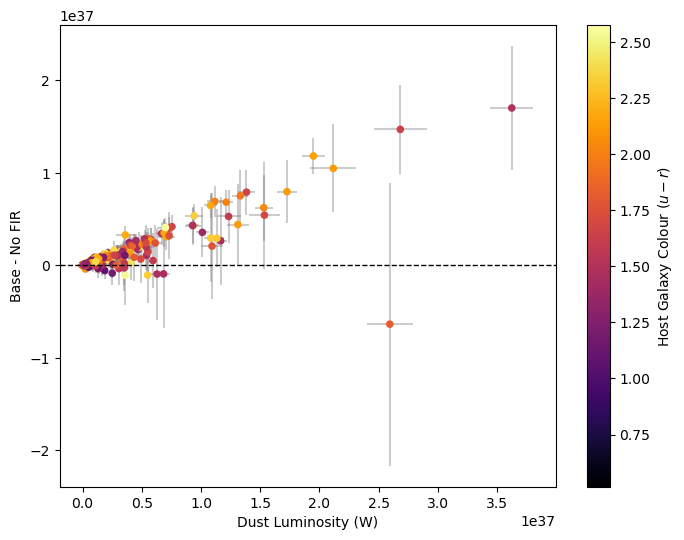

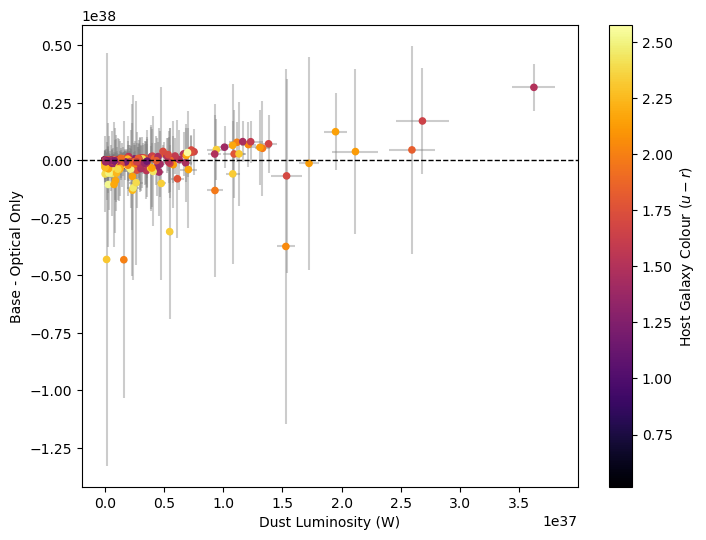

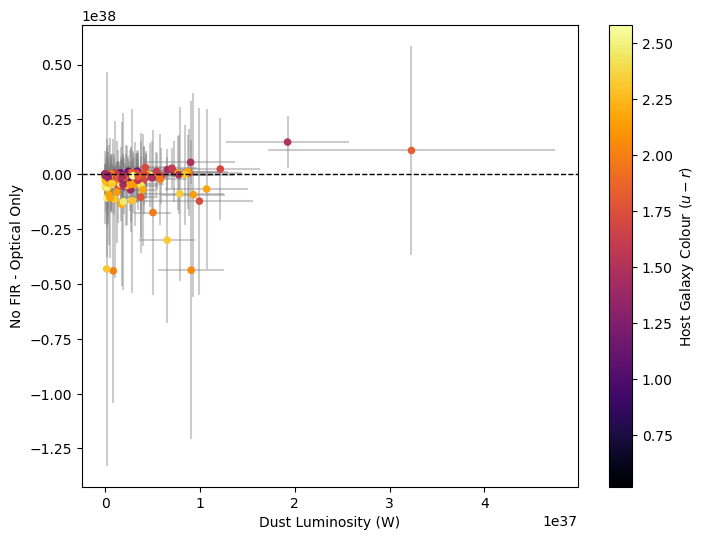

In [33]:
import matplotlib.pyplot as plt
plot_differences(baseproperties, nofirproperties, 'dustlum', 'dustlumerr',  'Dust Luminosity (W)', 'Base - No FIR', 'lower right', 'U-R colour')
plot_differences(baseproperties, opticalonlyproperties, 'dustlum', 'dustlumerr',  'Dust Luminosity (W)', 'Base - Optical Only', 'lower right', 'U-R colour')
plot_differences(nofirproperties, opticalonlyproperties, 'dustlum', 'dustlumerr',  'Dust Luminosity (W)', 'No FIR - Optical Only', 'lower right', 'U-R colour')

In [17]:
#include u-r colour
def compute_colour_u_r(org_df, treated_df):
    """u-r = -2.5 * log10(f_u / f_r).

    Error: sigma = (2.5/ln10) * sqrt((sigma_u/f_u)^2 + (sigma_r/f_r)^2)
    """
    f_u = org_df["bayes.sloan.sdss.u"]
    f_u_err = org_df["bayes.sloan.sdss.u_err"]
    f_r = org_df["bayes.sloan.sdss.r"]
    f_r_err = org_df["bayes.sloan.sdss.r_err"]

    colour = -2.5 * np.log10(f_u / f_r)
    colour_err = (2.5 / np.log(10)) * np.sqrt(
        (f_u_err / f_u) ** 2 + (f_r_err / f_r) ** 2
    )
    treated_df["bayes.colour_u_r"] = colour
    treated_df["bayes.colour_u_r_err"] = colour_err


In [18]:
compute_colour_u_r(baseresults, baseproperties)

In [19]:
compute_colour_u_r(nofirresults, nofirproperties)

In [20]:
baseproperties.head()

,id,Galaxy Mass (solMass),Galaxy Mass Error (solMass),Star Formation Rate (solMass yr-1),Star Formation Rate Error (solMass yr-1),Total Dust Mass (solMass),Total Dust Mass Error (solMass),Dust Luminosity (W),Dust Luminosity Error (W),bayes.dust.alpha,...,Av (mag),Av Error (mag),Average Galaxy Age (Myr),Average Galaxy Age Error (Myr),t,dist_best,Specific SFR (yr-1),Specific SFR Error (yr-1),bayes.colour_u_r,bayes.colour_u_r_err
0,NGC0584,9.583306e+10,1.171397e+10,0.023790,0.016410,1.291993e+36,6.943807e+35,5.583578e+35,1.190926e+35,2.0,...,0.072390,0.015579,6067.896647,1180.023151,-4.7,19.952632,2.482391e-13,1.739015e-13,2.456346,0.071614
1,NGC0586,9.048471e+09,1.570934e+09,0.040284,0.028256,4.915868e+36,1.371132e+36,3.793401e+35,4.784639e+34,2.0,...,0.274057,0.040251,4587.989486,1183.891925,0.7,24.931731,4.452065e-12,3.217012e-12,2.217274,0.083165
2,NGC0678,6.444807e+10,9.223424e+09,0.083906,0.061263,1.975071e+37,4.184584e+36,9.134661e+35,7.989181e+34,2.0,...,0.199237,0.025748,7963.503268,1494.293432,3.0,27.870000,1.301923e-12,9.686748e-13,2.578605,0.111781
3,NGC0855,8.975936e+08,1.960007e+08,0.027076,0.014076,4.024397e+35,1.136447e+35,1.241069e+35,1.443387e+34,2.0,...,0.230131,0.048937,1409.949168,704.396042,-4.8,9.638295,3.016561e-11,1.700944e-11,1.693638,0.086690
4,PGC008962,5.217925e+08,2.155807e+08,0.089609,0.009031,5.346987e+35,9.939652e+35,1.814277e+34,1.067646e+34,2.0,...,0.016576,0.011280,1842.355339,1230.184817,6.9,30.502458,1.717324e-10,7.303229e-11,1.201658,0.106341


In [21]:
# sed plotting time
